In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Display settings
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")
%matplotlib inline

In [3]:
project_root = os.path.dirname(os.getcwd())
data_path = os.path.join(project_root, "data", "raw", "WA_Fn-UseC_-Telco-Customer-Churn.csv")

df = pd.read_csv(data_path)
print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print("Churn Counts:\n", churn_counts)
print("\nChurn Percentage:\n", churn_pct.round(2))

Churn Counts:
 Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Percentage:
 Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


/var/folders/6q/38s__mqj0jv88pf4ms711b0r0000gn/T/ipykernel_4162/3002249519.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='Set2')


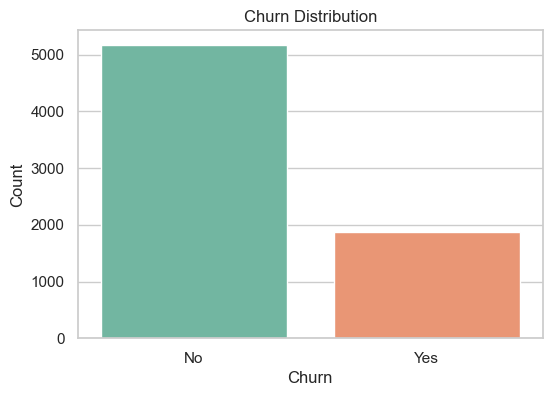

In [11]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, palette='Set2')
plt.title('Churn Distribution')
plt.ylabel('Count')
plt.savefig('../report/figures/churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

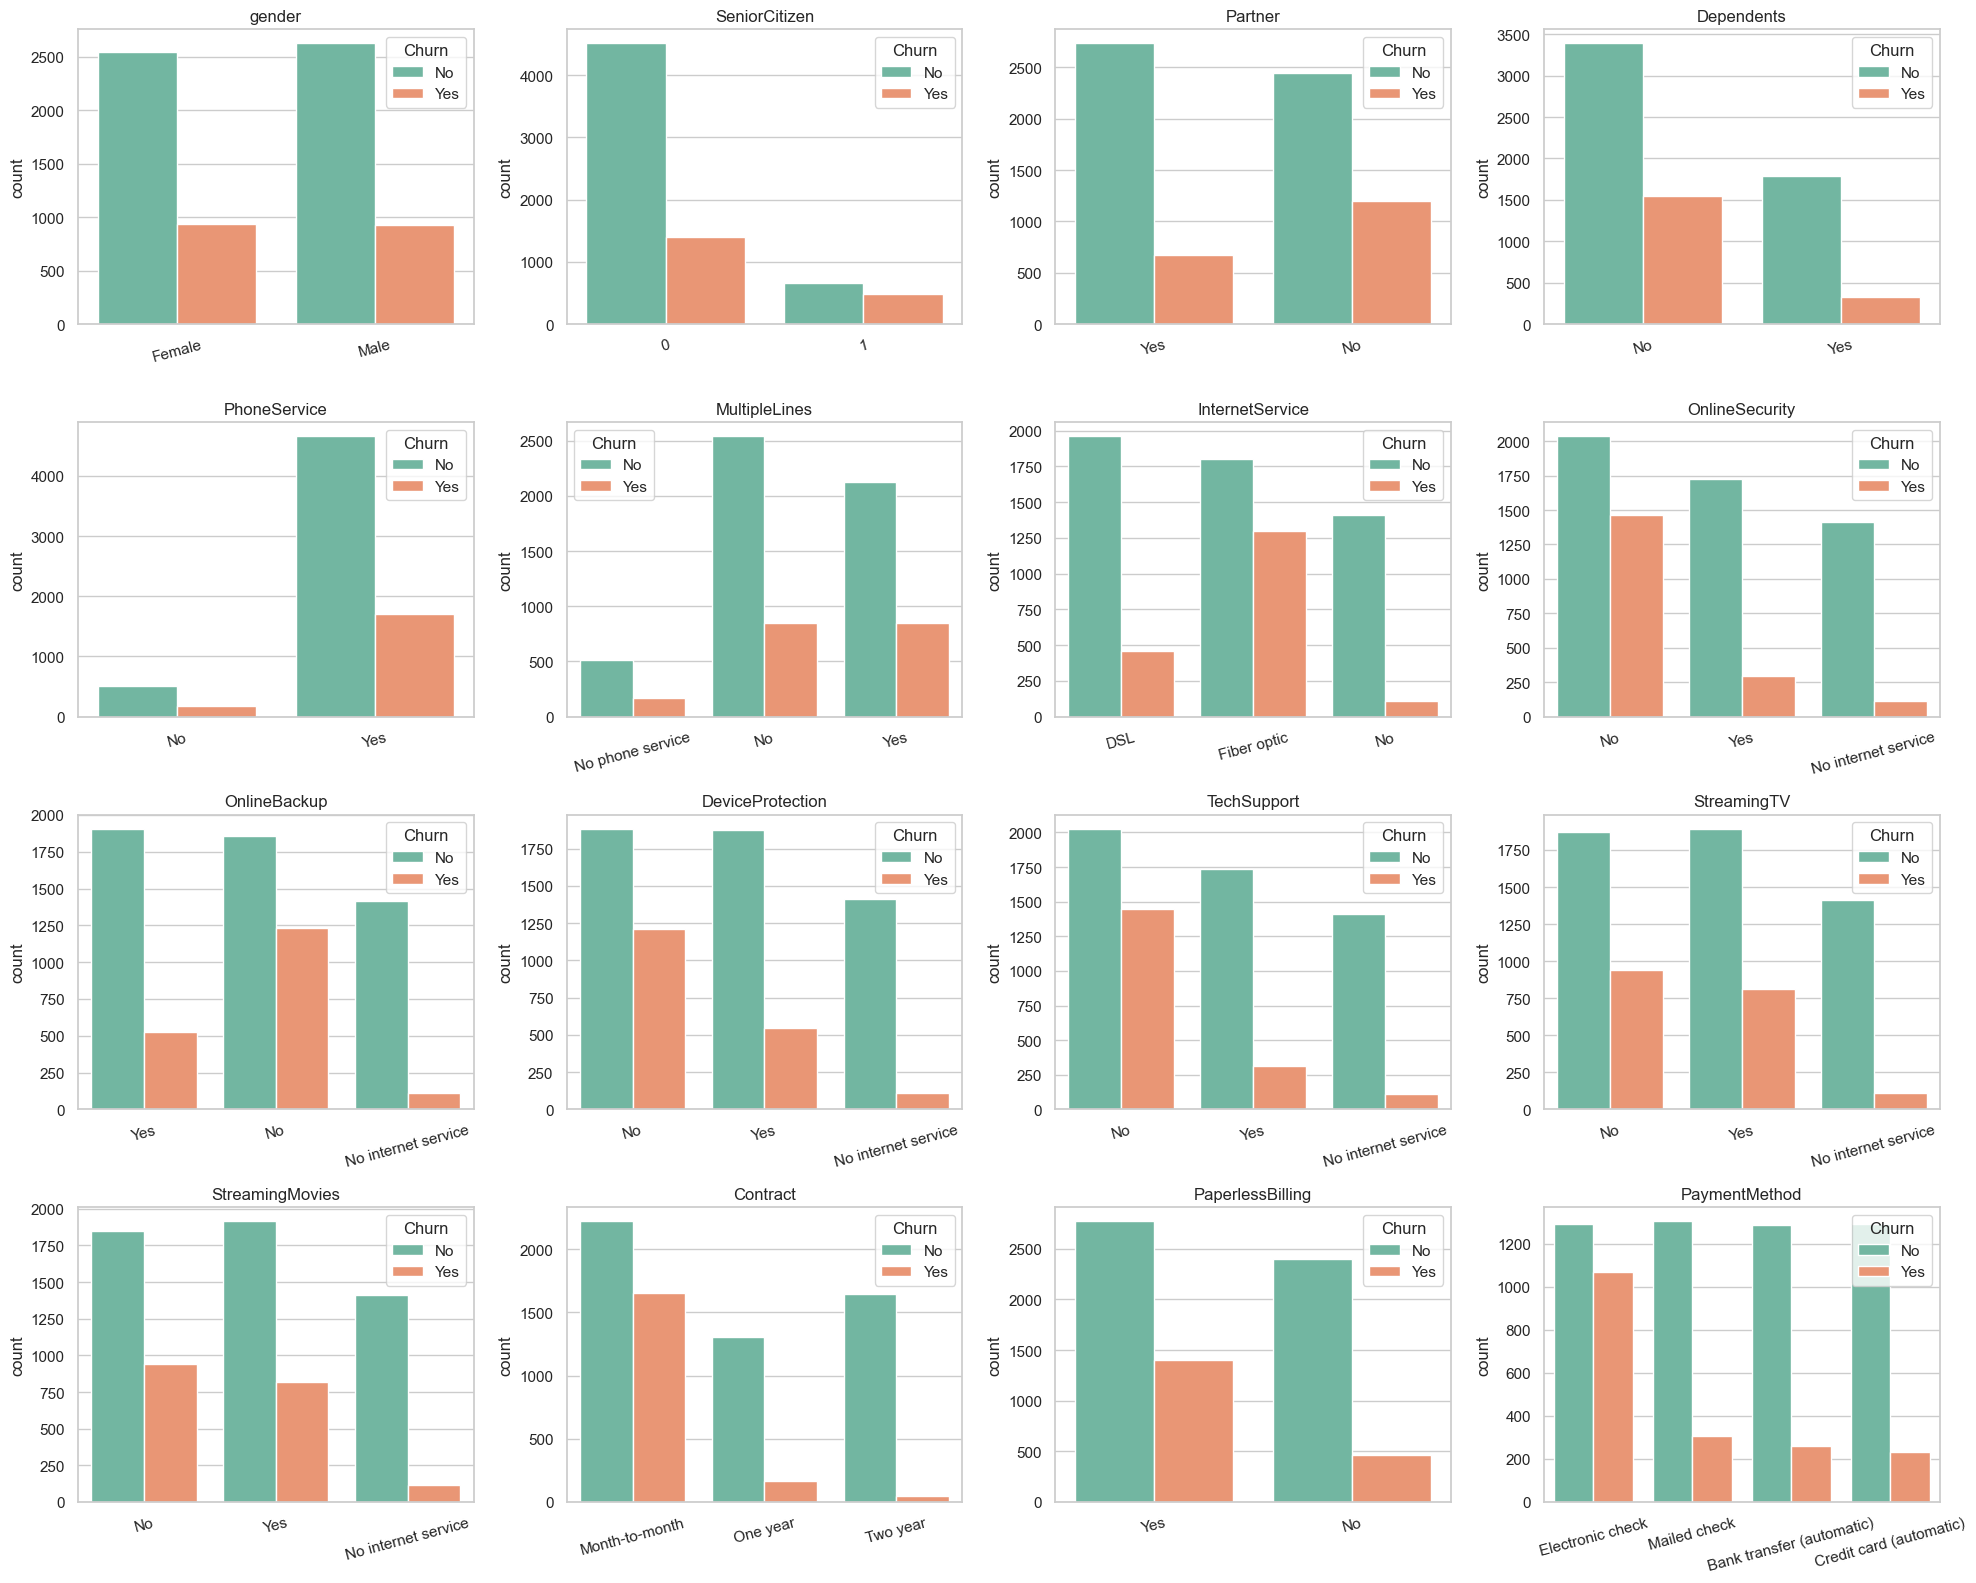

In [12]:
cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
            'PhoneService', 'MultipleLines', 'InternetService',
            'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'TechSupport', 'StreamingTV', 'StreamingMovies',
            'Contract', 'PaperlessBilling', 'PaymentMethod']

fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(x=col, hue='Churn', data=df, palette='Set2', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('../report/figures/categorical_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()

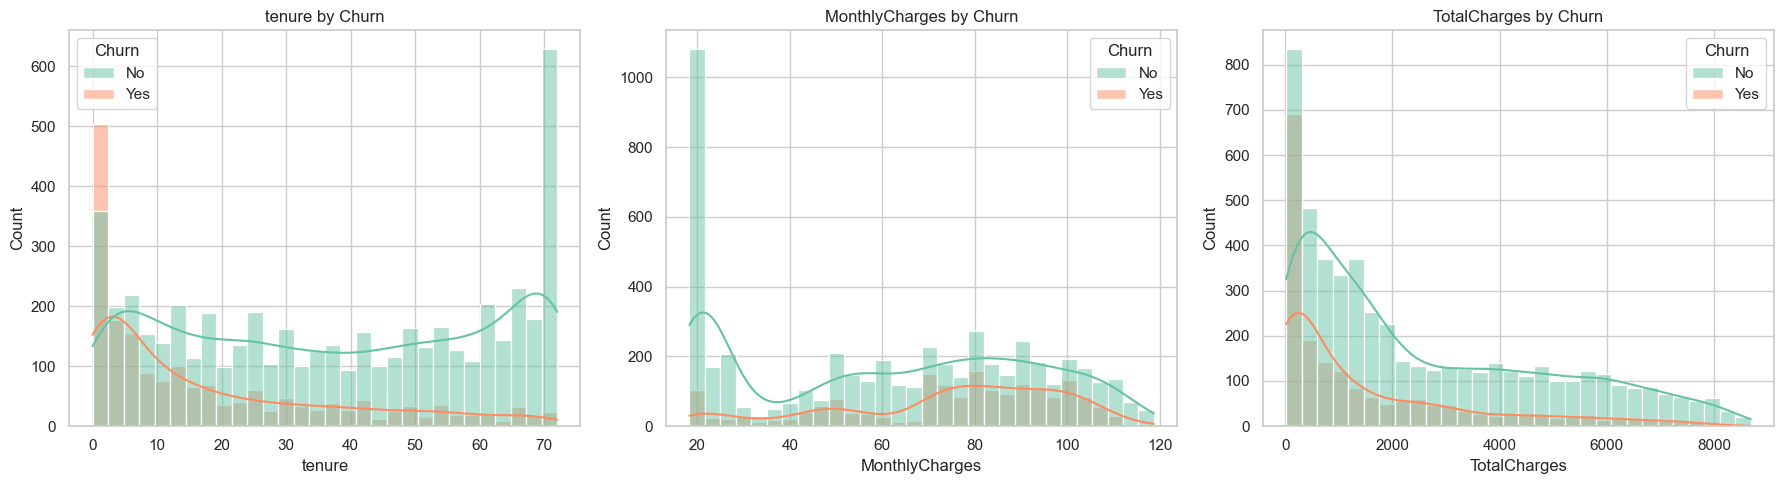

In [13]:
# Fix TotalCharges — it's stored as object, needs conversion
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, hue='Churn', kde=True,
                 palette='Set2', ax=axes[i], bins=30)
    axes[i].set_title(f'{col} by Churn')

plt.tight_layout()
plt.savefig('../report/figures/numerical_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()

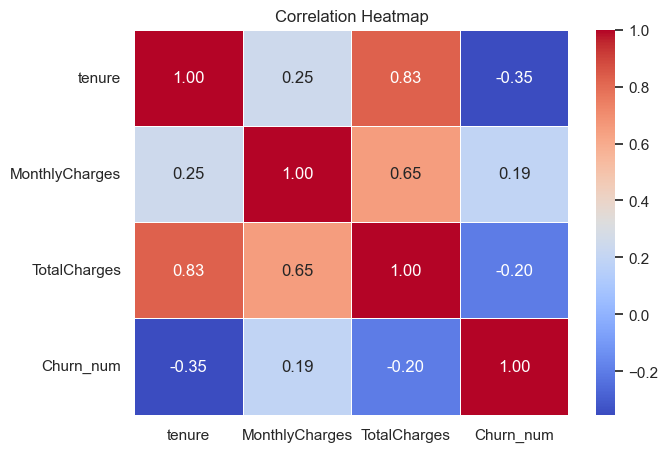

In [14]:
# Encode Churn temporarily for correlation
df_corr = df.copy()
df_corr['Churn_num'] = df_corr['Churn'].map({'Yes': 1, 'No': 0})

corr = df_corr[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_num']].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.savefig('../report/figures/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 📝 Key EDA Findings

- Dataset has 7,043 rows and 21 columns
- Churn rate is 26% dataset is imbalanced (will need SMOTE or class weights)
- TotalCharges has a few missing values (needs fixing in preprocessing)
- Customers on Month-to-Month contracts churn far more than yearly contracts
- Higher MonthlyCharges correlates with higher churn
- Customers with shorter tenure are more likely to churn
- Lack of OnlineSecurity and TechSupport strongly linked to churn